In [1]:
# Datos experimentales anotados directamente
frecuencias = [1e6, 2e6, 4e6]  # Frecuencias en Hz

In [5]:
import pandas as pd
import os

path = "data_in/"
#cacharros = ["Carga_1", "Carga_2", "Cable_1", "Cable_2"]
# cacharros = ["S"]

folders = [name for name in os.listdir(path)
           if os.path.isdir(os.path.join(path, name))]


path = "Carga_1/"

for folder in folders:
    for i in range(5):
        try:
            with open("data_in/" + folder + "/" + "CSV" + str(i +1) + ".csv") as file:
                text = file.read()
                text = text.split("Trace Data")

                data1 = text[1]
                data2 = text[2]

                data1 = data1.split("Trace Name")
                data1 = data1[0]

                data1.replace("Formatted Data", "S11")
                data2.replace("Formatted Data", "S12")

                data1.replace("\n", "")
                data2.replace("\n", "")

                # datos_df = pd.read_csv()
                # print(text[1])

            if not os.path.exists("data_out/" + folder):
                os.makedirs("data_out/" + folder)

            with open("data_out/" + folder + "/CSV" + str(i+1) + "_S11" + ".csv", "w") as file:
                file.write(data1)
            with open("data_out/" + folder + "/CSV" + str(i+1) + "_S21" + ".csv", "w") as file:
                file.write(data2)
        except:
            pass




# print(datos_df["Frequency"])

# datos_df = pd.read_csv(filepath + "CSV1.csv")



In [6]:
import pandas as pd
import numpy as np

ejpath = "data_out/Carga_1/CSV3_S21.csv"

# Leer datos desde un archivo CSV
datos_df = pd.read_csv(ejpath)

f = datos_df['Frequency']
f = f.to_numpy()



In [37]:
import numpy as np
import pandas as pd

cacharro = "Carga_1"

S_11 = []

for i in range(5):
    path = "data_out/" + cacharro + "/CSV" + str(i+1)
    
    datos = pd.read_csv(path + "_S11.csv")
    f_i = datos['Frequency']
    S_11 = [*S_11, datos['Formatted Data'].to_numpy()]
    f_i = f_i.to_numpy()

    datos = pd.read_csv(path + "_S21.csv")
    f = datos['Frequency']
    S_21 = datos['Formatted Data'].to_numpy()
    f = f.to_numpy()

S_11 = np.array(S_11)
print(S_11.shape)

    

(5, 201)


In [38]:
SVA = datos_df["Machine Module SVA1032X"]

print(SVA.IFBW)
# print(SVA.Trace)

KeyError: 'Machine Module SVA1032X'

In [ ]:
import numpy as np

# promedio_desfase = datos_df['Desfase'].mean()

array = datos_df.to_numpy()
S11 = array[:,1]
f = array[:,0]


IndexError: index 1 is out of bounds for axis 1 with size 1

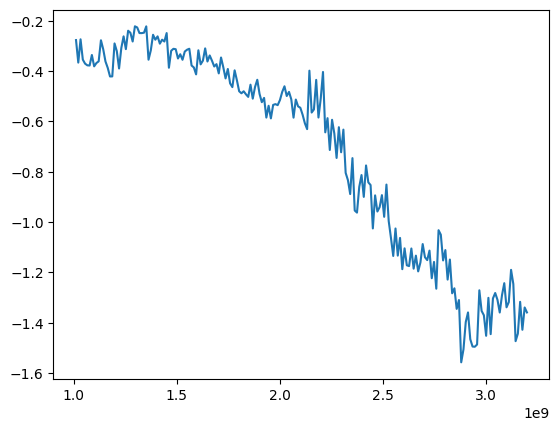

In [ ]:
import matplotlib.pyplot as plt

plt.plot(f, S11)
plt.show()